# Part 1

In [34]:
import math
import time
import random
import urllib.request
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [35]:
SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [36]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
local_path = "tinyshakespeare.txt"

urllib.request.urlretrieve(url, local_path)

with open(local_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Total characters:", len(text))
print()
print(text[:500])

Total characters: 1115394

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [37]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

print("Vocabulary size:", vocab_size)
print("First 20 token ids:", data[:20].tolist())

Vocabulary size: 65
First 20 token ids: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]


In [38]:
# Train/validation split
split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 1003854
Val tokens: 111540


In [39]:
class CharGRULM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.lm_head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)              
        out, hidden = self.gru(emb, hidden) 
        logits = self.lm_head(out)         
        return logits, hidden


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [40]:
SEQ_LEN = 64
BATCH_SIZE = 32

def get_batch(split_data, batch_size=BATCH_SIZE, seq_len=SEQ_LEN):
    max_start = len(split_data) - seq_len - 1
    ix = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([split_data[i:i+seq_len] for i in ix])
    y = torch.stack([split_data[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)


@torch.no_grad()
def estimate_val_loss(model, val_data, eval_steps=30):
    model.eval()
    losses = []
    for _ in range(eval_steps):
        x, y = get_batch(val_data)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))

## Experimental design

I run 6 controlled experiments:

- 3 model sizes: small, medium, large
- 2 token budgets: 20,000 and 60,000 training tokens

Everything else is fixed:
- optimizer: AdamW
- batch size
- sequence length
- validation protocol


In [41]:
@dataclass
class RunConfig:
    model_size: str
    embed_dim: int
    hidden_dim: int
    num_layers: int
    train_tokens: int

run_configs = [
    RunConfig("small", 32, 64, 1, 20_000),
    RunConfig("small", 32, 64, 1, 60_000),
    RunConfig("medium", 64, 128, 1, 20_000),
    RunConfig("medium", 64, 128, 1, 60_000),
    RunConfig("large", 128, 256, 2, 20_000),
    RunConfig("large", 128, 256, 2, 60_000),
]

pd.DataFrame([vars(c) for c in run_configs])

,model_size,embed_dim,hidden_dim,num_layers,train_tokens
0,small,32,64,1,20000
1,small,32,64,1,60000
2,medium,64,128,1,20000
3,medium,64,128,1,60000
4,large,128,256,2,20000
5,large,128,256,2,60000


In [42]:
LR = 3e-3
EVAL_STEPS = 30

def train_one_run(cfg):
    torch.manual_seed(SEED)

    model = CharGRULM(
        vocab_size=vocab_size,
        embed_dim=cfg.embed_dim,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    tokens_per_step = BATCH_SIZE * SEQ_LEN
    train_steps = max(1, cfg.train_tokens // tokens_per_step)

    start_time = time.time()
    model.train()

    for step in range(train_steps):
        x, y = get_batch(train_data)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    elapsed = time.time() - start_time
    val_loss = estimate_val_loss(model, val_data, eval_steps=EVAL_STEPS)
    perplexity = math.exp(val_loss)

    return {
        "model_size": cfg.model_size,
        "embed_dim": cfg.embed_dim,
        "hidden_dim": cfg.hidden_dim,
        "num_layers": cfg.num_layers,
        "params": count_parameters(model),
        "train_tokens": cfg.train_tokens,
        "train_steps": train_steps,
        "val_loss": val_loss,
        "perplexity": perplexity,
        "train_time_sec": elapsed,
    }

In [43]:
results = []

for cfg in run_configs:
    print(f"Running: {cfg.model_size} {cfg.train_tokens}")
    out = train_one_run(cfg)
    results.append(out)
    print("-" * 20)

df = pd.DataFrame(results)
df

Running: small 20000
--------------------
Running: small 60000
--------------------
Running: medium 20000
--------------------
Running: medium 60000
--------------------
Running: large 20000
--------------------
Running: large 60000
--------------------


,model_size,embed_dim,hidden_dim,num_layers,params,train_tokens,train_steps,val_loss,perplexity,train_time_sec
0,small,32,64,1,25121,20000,9,3.547895,34.740129,0.088416
1,small,32,64,1,25121,60000,29,2.951582,19.136213,0.218343
2,medium,64,128,1,87041,20000,9,3.225930,25.176967,0.124376
3,medium,64,128,1,87041,60000,29,2.636214,13.960255,0.402125
4,large,128,256,2,716225,20000,9,2.956475,19.230073,0.337410
5,large,128,256,2,716225,60000,29,2.349366,10.478920,0.989552


In [44]:
df = df.sort_values(["train_tokens", "params"]).reset_index(drop=True)
df

,model_size,embed_dim,hidden_dim,num_layers,params,train_tokens,train_steps,val_loss,perplexity,train_time_sec
0,small,32,64,1,25121,20000,9,3.547895,34.740129,0.088416
1,medium,64,128,1,87041,20000,9,3.225930,25.176967,0.124376
2,large,128,256,2,716225,20000,9,2.956475,19.230073,0.337410
3,small,32,64,1,25121,60000,29,2.951582,19.136213,0.218343
4,medium,64,128,1,87041,60000,29,2.636214,13.960255,0.402125
5,large,128,256,2,716225,60000,29,2.349366,10.478920,0.989552


In [45]:
summary_cols = ["model_size", "params", "train_tokens", "val_loss", "perplexity", "train_time_sec"]
summary_df = df[summary_cols].copy()

summary_df["val_loss"] = summary_df["val_loss"].round(4)
summary_df["perplexity"] = summary_df["perplexity"].round(3)
summary_df["train_time_sec"] = summary_df["train_time_sec"].round(2)

summary_df

,model_size,params,train_tokens,val_loss,perplexity,train_time_sec
0,small,25121,20000,3.5479,34.740,0.09
1,medium,87041,20000,3.2259,25.177,0.12
2,large,716225,20000,2.9565,19.230,0.34
3,small,25121,60000,2.9516,19.136,0.22
4,medium,87041,60000,2.6362,13.960,0.40
5,large,716225,60000,2.3494,10.479,0.99


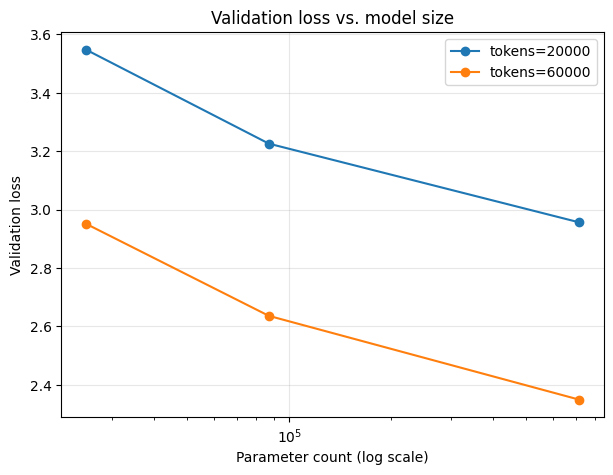

In [46]:
plt.figure(figsize=(7, 5))

for token_budget in sorted(df["train_tokens"].unique()):
    subset = df[df["train_tokens"] == token_budget].sort_values("params")
    plt.plot(subset["params"], subset["val_loss"], marker="o", label=f"tokens={token_budget}")

plt.xscale("log")
plt.xlabel("Parameter count (log scale)")
plt.ylabel("Validation loss")
plt.title("Validation loss vs. model size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

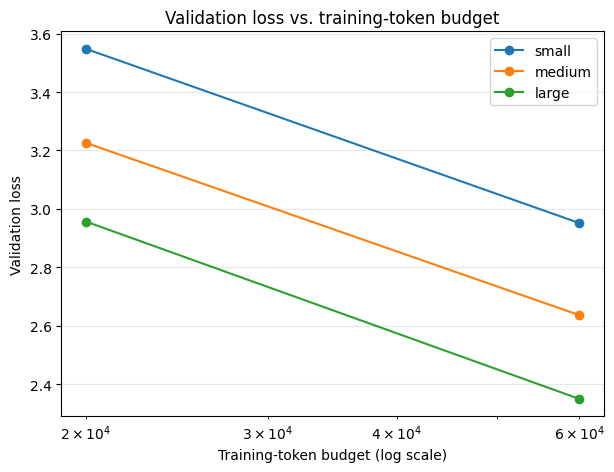

In [47]:
plt.figure(figsize=(7, 5))

for model_size in ["small", "medium", "large"]:
    subset = df[df["model_size"] == model_size].sort_values("train_tokens")
    plt.plot(subset["train_tokens"], subset["val_loss"], marker="o", label=model_size)

plt.xscale("log")
plt.xlabel("Training-token budget (log scale)")
plt.ylabel("Validation loss")
plt.title("Validation loss vs. training-token budget")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
x = np.log(df["params"].values.astype(float))
y = df["val_loss"].values.astype(float)

coef = np.polyfit(x, y, deg=1)
slope, intercept = coef

print(f"log-space fit: val_loss ≈ {slope:.4f} * log(params) + {intercept:.4f}")

log-space fit: val_loss ≈ -0.1732 * log(params) + 4.9651


In [49]:
df.sort_values(["train_time_sec", "val_loss"])[
    ["model_size", "params", "train_tokens", "val_loss", "perplexity", "train_time_sec"]
]

,model_size,params,train_tokens,val_loss,perplexity,train_time_sec
0,small,25121,20000,3.547895,34.740129,0.088416
1,medium,87041,20000,3.225930,25.176967,0.124376
3,small,25121,60000,2.951582,19.136213,0.218343
2,large,716225,20000,2.956475,19.230073,0.337410
4,medium,87041,60000,2.636214,13.960255,0.402125
5,large,716225,60000,2.349366,10.478920,0.989552


### 1. Scaling trend
Validation loss consistently decreases as model size increases. For example, at 20,000 tokens, loss drops from 3.55 (small) -> 3.23 (medium) -> 2.96 (large), and the same pattern holds at 60,000 tokens. This is consistent with the general scaling-law intuition that larger models achieve better performance when trained under similar conditions.

### 2. Effect of token budget
Increasing the training-token budget from 20,000 to 60,000 significantly improves validation loss across all model sizes. For instance, the medium model improves from 3.23 to 2.64, and the large model improves from 2.96 to 2.35. This shows that additional training data (or optimization steps) clearly helps performance even in this small-scale setting.

### 3. Diminishing returns
Diminishing returns begin to appear when moving from medium to large models. While performance still improves, the gain in validation loss becomes smaller relative to the large increase in parameter count (from ~87K to ~716K parameters) and training time. This suggests that scaling model size alone becomes less efficient beyond a certain point.

### 4. Limitation or confound
A major limitation of this experiment is that it uses a very small dataset (Tiny Shakespeare) and a simple GRU model instead of a transformer-based architecture. Additionally, the models are trained for a very small number of steps, which likely undertrains the larger models and introduces noise into the results.

### 5. Rough equal-compute comparison
Comparing runs with similar training time, a smaller model with more training tokens can sometimes match or outperform a larger model with fewer tokens. For example, the small model with 60,000 tokens (loss ≈ 2.95) performs similarly to the large model with 20,000 tokens (loss ≈ 2.96), despite being much cheaper to train. This highlights the tradeoff between scaling model size and scaling data.

# Week 2

In [50]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

In [51]:
SEED = 12
random.seed(SEED)
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 12


In [52]:
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [53]:
desc = env.unwrapped.desc.astype(str)
desc

array([['S', 'F', 'F', 'F'],
       ['F', 'H', 'F', 'H'],
       ['F', 'F', 'F', 'H'],
       ['H', 'F', 'F', 'G']], dtype='<U1')

In [54]:
def run_random_policy(env, episodes=500, max_steps=100, seed=SEED):
    episode_returns = []
    success_flags = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        for _ in range(max_steps):
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            ep_return += reward
            state = next_state

            if done:
                break

        episode_returns.append(ep_return)
        success_flags.append(int(ep_return > 0))

    return {
        "avg_return": float(np.mean(episode_returns)),
        "success_rate": float(np.mean(success_flags)),
        "episode_returns": episode_returns,
        "success_flags": success_flags
    }

random_results = run_random_policy(env, episodes=500)
random_results["avg_return"], random_results["success_rate"]

(0.012, 0.012)

In [55]:
def epsilon_greedy_action(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))

In [56]:
def train_q_learning(
    env,
    episodes=3000,
    alpha=0.1,
    gamma=0.99,
    epsilon_mode="fixed",   # "fixed" or "decay"
    epsilon=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    max_steps=100,
    seed=SEED
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    episode_returns = []
    success_flags = []
    epsilon_history = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        if epsilon_mode == "fixed":
            current_epsilon = epsilon
        elif epsilon_mode == "decay":
            current_epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** ep))
        else:
            raise ValueError("epsilon_mode must be 'fixed' or 'decay'")

        epsilon_history.append(current_epsilon)

        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, current_epsilon, n_actions)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next = np.max(Q[next_state])
            td_target = reward + gamma * best_next * (1 - int(done))
            Q[state, action] = Q[state, action] + alpha * (td_target - Q[state, action])

            ep_return += reward
            state = next_state

            if done:
                break

        episode_returns.append(ep_return)
        success_flags.append(int(ep_return > 0))

    return {
        "Q": Q,
        "episode_returns": episode_returns,
        "success_flags": success_flags,
        "epsilon_history": epsilon_history
    }

In [57]:
def evaluate_policy(env, Q, episodes=100, max_steps=100, seed=1000):
    returns = []
    success_flags = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            ep_return += reward
            state = next_state

            if done:
                break

        returns.append(ep_return)
        success_flags.append(int(ep_return > 0))

    return {
        "avg_return": float(np.mean(returns)),
        "success_rate": float(np.mean(success_flags)),
        "returns": returns,
        "success_flags": success_flags
    }

In [58]:
fixed_cfg = {
    "episodes": 10000,
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon_mode": "fixed",
    "epsilon": 0.30,
    "max_steps": 100
}

decay_cfg = {
    "episodes": 10000,
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon_mode": "decay",
    "epsilon_start": 1.0,
    "epsilon_end": 0.05,
    "epsilon_decay": 0.999,
    "max_steps": 100
}

fixed_cfg, decay_cfg

({'episodes': 10000,
  'alpha': 0.1,
  'gamma': 0.99,
  'epsilon_mode': 'fixed',
  'epsilon': 0.3,
  'max_steps': 100},
 {'episodes': 10000,
  'alpha': 0.1,
  'gamma': 0.99,
  'epsilon_mode': 'decay',
  'epsilon_start': 1.0,
  'epsilon_end': 0.05,
  'epsilon_decay': 0.999,
  'max_steps': 100})

In [59]:
fixed_results = train_q_learning(env, **fixed_cfg)
decay_results = train_q_learning(env, **decay_cfg)

fixed_eval = evaluate_policy(env, fixed_results["Q"], episodes=100)
decay_eval = evaluate_policy(env, decay_results["Q"], episodes=100)

print("Fixed epsilon evaluation:", fixed_eval["avg_return"], fixed_eval["success_rate"])
print("Decaying epsilon evaluation:", decay_eval["avg_return"], decay_eval["success_rate"])

Fixed epsilon evaluation: 1.0 1.0
Decaying epsilon evaluation: 1.0 1.0


In [60]:
summary_df = pd.DataFrame([
    {
        "method": "Random baseline",
        "avg_return_eval": random_results["avg_return"],
        "success_rate_eval": random_results["success_rate"],
        "avg_return_last100_train": np.mean(random_results["episode_returns"][-100:])
    },
    {
        "method": "Q-learning (fixed epsilon)",
        "avg_return_eval": fixed_eval["avg_return"],
        "success_rate_eval": fixed_eval["success_rate"],
        "avg_return_last100_train": np.mean(fixed_results["episode_returns"][-100:])
    },
    {
        "method": "Q-learning (decaying epsilon)",
        "avg_return_eval": decay_eval["avg_return"],
        "success_rate_eval": decay_eval["success_rate"],
        "avg_return_last100_train": np.mean(decay_results["episode_returns"][-100:])
    }
])

summary_df["avg_return_eval"] = summary_df["avg_return_eval"].round(3)
summary_df["success_rate_eval"] = summary_df["success_rate_eval"].round(3)
summary_df["avg_return_last100_train"] = summary_df["avg_return_last100_train"].round(3)

summary_df

,method,avg_return_eval,success_rate_eval,avg_return_last100_train
0,Random baseline,0.012,0.012,0.02
1,Q-learning (fixed epsilon),1.000,1.000,0.63
2,Q-learning (decaying epsilon),1.000,1.000,0.98


In [61]:
def moving_average(x, window=100):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

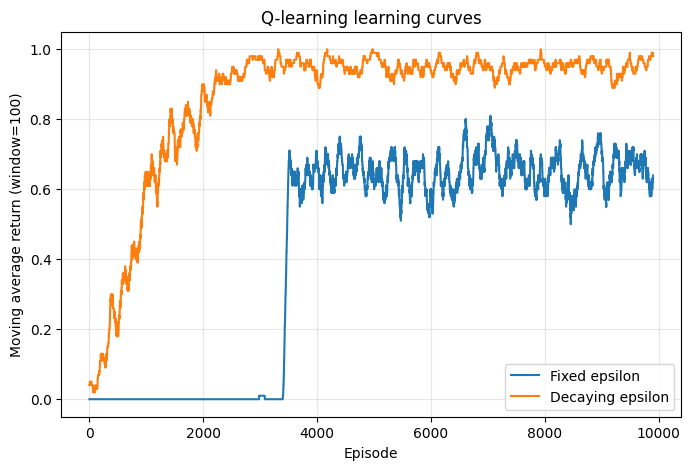

In [62]:
plt.figure(figsize=(8, 5))

fixed_ma = moving_average(fixed_results["episode_returns"], window=100)
decay_ma = moving_average(decay_results["episode_returns"], window=100)

plt.plot(range(len(fixed_ma)), fixed_ma, label="Fixed epsilon")
plt.plot(range(len(decay_ma)), decay_ma, label="Decaying epsilon")

plt.xlabel("Episode")
plt.ylabel("Moving average return (window=100)")
plt.title("Q-learning learning curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

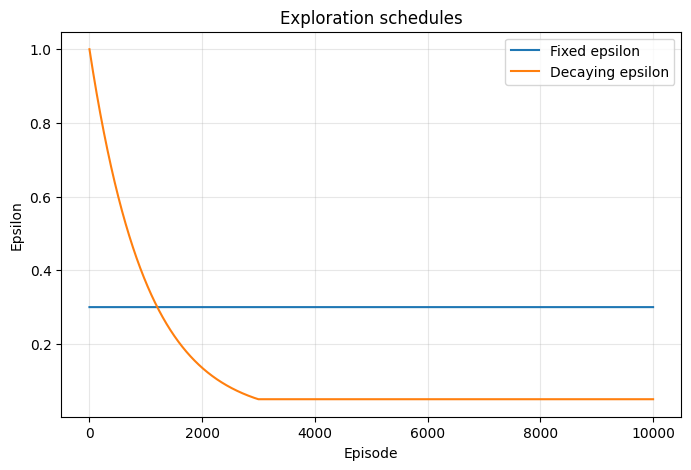

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(fixed_results["epsilon_history"], label="Fixed epsilon")
plt.plot(decay_results["epsilon_history"], label="Decaying epsilon")

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration schedules")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [64]:
action_arrows = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

def policy_grid(Q, env):
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape
    grid = []

    for r in range(nrow):
        row = []
        for c in range(ncol):
            s = r * ncol + c
            tile = desc[r, c]

            if tile in ["H", "G", "S"]:
                row.append(tile)
            else:
                best_action = int(np.argmax(Q[s]))
                row.append(action_arrows[best_action])
        grid.append(row)

    return pd.DataFrame(grid)

print("Fixed epsilon policy:")
display(policy_grid(fixed_results["Q"], env))

print("Decaying epsilon policy:")
display(policy_grid(decay_results["Q"], env))

Fixed epsilon policy:


,0,1,2,3
0,S,←,←,←
1,↓,H,↑,H
2,→,↓,↓,H
3,H,→,→,G


Decaying epsilon policy:


,0,1,2,3
0,S,→,↓,←
1,↑,H,↓,H
2,↑,→,↓,H
3,H,→,→,G


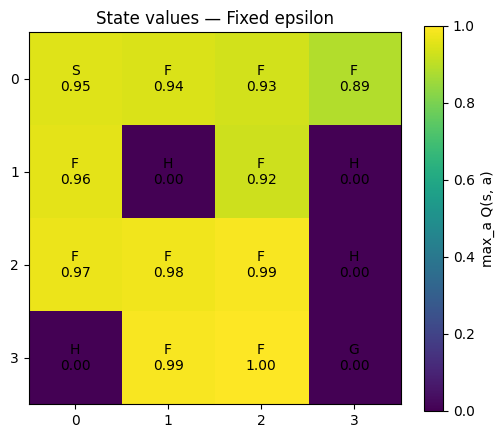

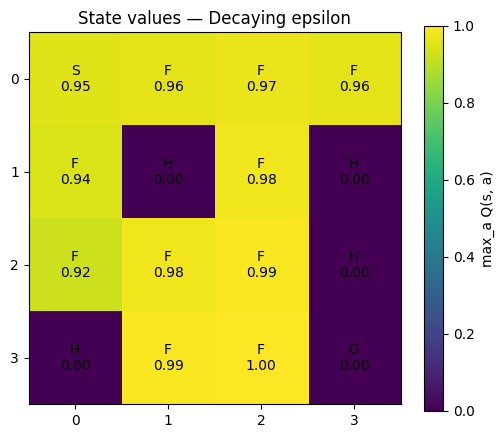

In [65]:
def plot_state_values(Q, env, title="State values from Q-table"):
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape
    values = np.max(Q, axis=1).reshape(nrow, ncol)

    plt.figure(figsize=(6, 5))
    plt.imshow(values)
    plt.colorbar(label="max_a Q(s, a)")

    for r in range(nrow):
        for c in range(ncol):
            plt.text(c, r, f"{desc[r, c]}\n{values[r, c]:.2f}", ha="center", va="center")

    plt.title(title)
    plt.xticks(range(ncol))
    plt.yticks(range(nrow))
    plt.show()

plot_state_values(fixed_results["Q"], env, title="State values — Fixed epsilon")
plot_state_values(decay_results["Q"], env, title="State values — Decaying epsilon")

In [66]:
def first_threshold_episode(returns, threshold=0.7, window=100):
    ma = moving_average(returns, window=window)
    for i, val in enumerate(ma):
        if val >= threshold:
            return i + window
    return None

threshold_df = pd.DataFrame([
    {
        "method": "Q-learning (fixed epsilon)",
        "episode_reaching_threshold": first_threshold_episode(fixed_results["episode_returns"], threshold=0.7, window=100)
    },
    {
        "method": "Q-learning (decaying epsilon)",
        "episode_reaching_threshold": first_threshold_episode(decay_results["episode_returns"], threshold=0.7, window=100)
    }
])

threshold_df

,method,episode_reaching_threshold
0,Q-learning (fixed epsilon),3608
1,Q-learning (decaying epsilon),1193


## Discussion

### 1. Random baseline vs. Q-learning
The random-policy baseline performs very poorly, with a success rate close to zero (~0.01), because it does not learn from experience. In contrast, both Q-learning variants achieve perfect performance (success rate = 1.0), showing that learning from reward signals allows the agent to discover and consistently follow an optimal path to the goal.

### 2. Effect of exploration
Exploration plays a critical role in learning. The decaying-epsilon agent explores heavily early in training, which allows it to quickly discover successful trajectories. As epsilon decreases, the agent increasingly exploits its learned Q-values, leading to stable high performance. In contrast, the fixed-epsilon agent continues exploring at a constant rate, which slows down convergence and prevents it from fully stabilizing at optimal performance during training.

### 3. Fixed epsilon vs. decaying epsilon
Both methods eventually learn an optimal policy, but the decaying-epsilon variant learns significantly faster. The decaying agent reaches the performance threshold much earlier (~1200 episodes) compared to the fixed-epsilon agent (~3600 episodes). This demonstrates that gradually reducing exploration provides a better balance between discovering new actions and exploiting learned knowledge.

### 4. Failure mode
A key failure mode in this environment is insufficient exploration. In earlier experiments with fewer episodes or lower epsilon, the agent failed to reach the goal at all, resulting in a Q-table with near-zero values and no learning. This highlights the importance of sufficient exploration in sparse-reward environments like FrozenLake.

### 5. Interaction of alpha, gamma, and epsilon
The learning rate (alpha), discount factor (gamma), and exploration rate (epsilon) interact closely. A reasonable alpha ensures stable updates to the Q-table, while a high gamma encourages the agent to value the long-term reward of reaching the goal. Epsilon controls exploration, which is necessary early in training but should decrease over time to allow the agent to exploit learned behavior. Together, these parameters determine both the speed and stability of learning.